In [1]:
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

In [99]:
# Candidate to make the heatmap of
protein = "GPR37L1"

In [448]:
# order to show the metrics and hippocampal layers

metric_order = [
    "presynapse_image_mfi", 
    "pre_staining_area_um2",
    "pre_puncta_density_per_100_um2",
    "pre_mean_puncta_size_um2",
    "postsynapse_image_mfi",
    "post_staining_area_um2",
    "post_puncta_density_per_100_um2",
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ]

vlgut1_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

vlgut2_hippocampal_layer_order = [
    "Subiculum SP",
    "CA2 SP",
    "DG GC",
    "Cortex L4"
    ]

vgat_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

In [100]:
# reading in the VGLUT1-PSD95 dataset
file_path_vglut1 = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGLUT1-PSD95_output_data/all_statistics.csv"
df_vglut1 = pd.read_csv(file_path_vglut1).set_index(['Unnamed: 0'])
df_vglut1.head(10)

,hippocampal_layer,metric,p_value,statistical significant?
Unnamed: 0,,,,
0,CA1 SO,overlap_um2,0.168625,No
1,CA1 SO,pearson_cor,0.663899,No
2,CA1 SO,overlap_coeff,0.102008,No
3,CA1 SO,local_peak_colocalized_spots,0.891995,No
4,CA1 SO,presynapse_image_mfi,0.350425,No
5,CA1 SO,postsynapse_image_mfi,0.105210,No
6,CA1 SO,pre_puncta_density_per_100_um2,0.832029,No
7,CA1 SO,post_puncta_density_per_100_um2,0.452804,No
8,CA1 SO,pre_staining_area_um2,0.367039,No


In [101]:
df_vglut1_2 = df_vglut1.pivot(index="metric", columns="hippocampal_layer", values="p_value").reindex(metric_order)
df_vglut1_2 = df_vglut1_2[vlgut1_hippocampal_layer_order]
df_vglut1_2.head(15)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
metric,,,,,,,,
presynapse_image_mfi,0.350425,0.273257,0.355068,0.584214,0.397673,0.436278,0.612759,0.364659
pre_staining_area_um2,0.367039,0.780123,0.166189,0.859552,0.673375,0.009264,0.098946,0.636606
pre_puncta_density_per_100_um2,0.832029,0.672638,0.093195,0.312945,0.118663,0.005325,0.159163,0.787191
pre_mean_puncta_size_um2,0.044460,0.633252,0.742294,0.645628,0.805850,0.022639,0.306383,0.446559
postsynapse_image_mfi,0.105210,0.708242,0.583949,0.308827,0.506013,0.311291,0.233510,0.797861
post_staining_area_um2,0.737136,0.728603,0.294158,0.466880,0.729865,0.705745,0.745665,0.735584
post_puncta_density_per_100_um2,0.452804,0.441238,0.006424,0.498749,0.606609,0.399208,0.221585,0.527951
post_mean_puncta_size_um2,0.110105,0.317928,0.223754,0.987025,0.824763,0.227647,0.361642,0.887293
local_peak_colocalized_spots,0.891995,0.402411,0.736495,0.701880,0.903917,0.528725,0.225365,0.755568


/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/2368317078.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = df_vglut1_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


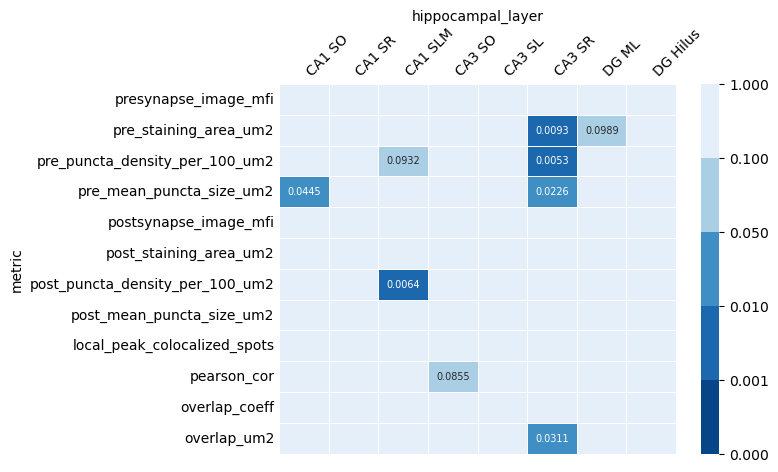

In [102]:
# myColors = ((0.8, 0.0, 0.0, 1.0), (0.0, 0.8, 0.0, 1.0), (0.0, 0.0, 0.8, 1.0))
# cmap = LinearSegmentedColormap.from_list('Custom', myColors, len(myColors))
# cmap = sns.color_palette('RdBu_r', n_colors = 5)

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

mask = df_vglut1_2 < 0.1
annotations = df_vglut1_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


ax = sns.heatmap(data=df_vglut1_2, annot=annotations, fmt = "", annot_kws={"fontsize": 7}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.show()

In [103]:
file_path_vglut2 = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGLUT2-PSD95_output_data/all_statistics.csv"
df_vglut2 = pd.read_csv(file_path_vglut2).set_index(['Unnamed: 0'])
df_vglut2.head(20)

,hippocampal_layer,metric,p_value,statistical significant?
Unnamed: 0,,,,
0,CA2 SP,overlap_um2,0.830845,No
1,CA2 SP,pearson_cor,0.317401,No
2,CA2 SP,overlap_coeff,0.961844,No
3,CA2 SP,local_peak_colocalized_spots,0.810712,No
4,CA2 SP,presynapse_image_mfi,0.672212,No
5,CA2 SP,postsynapse_image_mfi,0.774840,No
6,CA2 SP,pre_puncta_density_per_100_um2,0.232041,No
7,CA2 SP,post_puncta_density_per_100_um2,0.780512,No
8,CA2 SP,pre_staining_area_um2,0.368660,No


In [104]:
df_vglut2_2 = df_vglut2.pivot(index="metric", columns="hippocampal_layer", values="p_value").reindex(metric_order)
df_vglut2_2 = df_vglut2_2[vlgut2_hippocampal_layer_order]
df_vglut2_2.head(20)

hippocampal_layer,Subiculum SP,CA2 SP,DG GC,Cortex L4
metric,,,,
presynapse_image_mfi,0.026515,0.672212,0.511680,0.508557
pre_staining_area_um2,0.867419,0.368660,0.100040,0.077542
pre_puncta_density_per_100_um2,0.958830,0.232041,0.279730,0.143207
pre_mean_puncta_size_um2,0.721060,0.924056,0.009978,0.046602
postsynapse_image_mfi,0.923429,0.774840,0.826857,0.191042
post_staining_area_um2,0.076556,0.926745,0.123293,0.342925
post_puncta_density_per_100_um2,0.582328,0.780512,0.118444,0.295062
post_mean_puncta_size_um2,0.682893,0.870329,0.625242,0.817981
local_peak_colocalized_spots,0.163978,0.810712,0.462776,0.621130


In [105]:
# filter out the VGLUT2 postsynaptic metrics and the coloc metrics (not trustworhty)

# Define rows to be set to NA and column to exclude
rows_to_set_na = [
    "postsynapse_image_mfi", 
    "post_staining_area_um2", 
    "post_puncta_density_per_100_um2", 
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ] 

column_to_exclude = "Cortex L4"  # Column to exclude from NA

# Set NA values for specified rows and all columns except the excluded one
df_vglut2_2.loc[rows_to_set_na, df_vglut2_2.columns != column_to_exclude] = np.nan

df_vglut2_2.head(15)

hippocampal_layer,Subiculum SP,CA2 SP,DG GC,Cortex L4
metric,,,,
presynapse_image_mfi,0.026515,0.672212,0.511680,0.508557
pre_staining_area_um2,0.867419,0.368660,0.100040,0.077542
pre_puncta_density_per_100_um2,0.958830,0.232041,0.279730,0.143207
pre_mean_puncta_size_um2,0.721060,0.924056,0.009978,0.046602
postsynapse_image_mfi,NaN,NaN,NaN,0.191042
post_staining_area_um2,NaN,NaN,NaN,0.342925
post_puncta_density_per_100_um2,NaN,NaN,NaN,0.295062
post_mean_puncta_size_um2,NaN,NaN,NaN,0.817981
local_peak_colocalized_spots,NaN,NaN,NaN,0.621130


/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/1349620984.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = df_vglut2_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


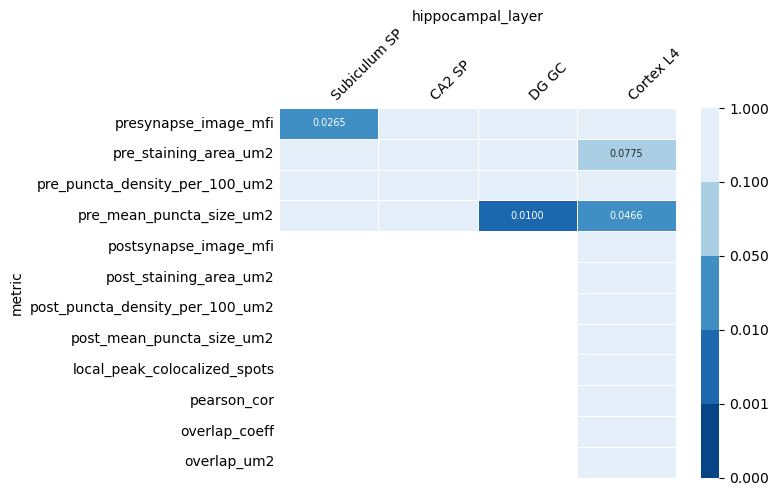

In [106]:
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

mask = df_vglut2_2 < 0.1
annotations = df_vglut2_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


ax = sns.heatmap(data=df_vglut2_2, annot=annotations, fmt = "", annot_kws={"fontsize": 7}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.show()

In [107]:
file_path_vgat = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGAT-GEPH_output_data/all_statistics.csv"
df_vgat = pd.read_csv(file_path_vgat).set_index(['Unnamed: 0'])
df_vgat.head(20)

,hippocampal_layer,metric,p_value,statistical significant?
Unnamed: 0,,,,
0,CA1 SO,overlap_um2,0.727000,No
1,CA1 SO,pearson_cor,0.707798,No
2,CA1 SO,overlap_coeff,0.683336,No
3,CA1 SO,local_peak_colocalized_spots,0.877601,No
4,CA1 SO,presynapse_image_mfi,0.652028,No
5,CA1 SO,postsynapse_image_mfi,0.394291,No
6,CA1 SO,pre_puncta_density_per_100_um2,0.759623,No
7,CA1 SO,post_puncta_density_per_100_um2,0.714266,No
8,CA1 SO,pre_staining_area_um2,0.673862,No


In [108]:
df_vgat_2 = df_vgat.pivot(index="metric", columns="hippocampal_layer", values="p_value").reindex(metric_order)
df_vgat_2 = df_vgat_2[vgat_hippocampal_layer_order]
df_vgat_2.head(15)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
metric,,,,,,,,
presynapse_image_mfi,0.652028,0.475835,0.889218,0.549813,0.570942,0.458606,0.653855,0.846560
pre_staining_area_um2,0.673862,0.776181,0.804536,0.320818,0.411189,0.359517,0.983064,0.221965
pre_puncta_density_per_100_um2,0.759623,0.988219,0.748815,0.265141,0.517809,0.904597,0.975540,0.280671
pre_mean_puncta_size_um2,0.460005,0.643713,0.497501,0.589401,0.819611,0.279551,0.891637,0.552817
postsynapse_image_mfi,0.394291,0.439417,0.580043,0.857887,0.530152,0.450245,0.507814,0.948524
post_staining_area_um2,0.969782,0.439905,0.382263,0.161537,0.997440,0.292988,0.489321,0.344821
post_puncta_density_per_100_um2,0.714266,0.452834,0.356285,0.165641,0.944535,0.329789,0.493883,0.816788
post_mean_puncta_size_um2,0.250829,0.292954,0.283520,0.253415,0.380457,0.281488,0.374860,0.357388
local_peak_colocalized_spots,0.877601,0.293690,0.772699,0.643085,0.808781,0.035768,0.613752,0.088023


/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/702481353.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = df_vgat_2.applymap(lambda x: f'{x:.4f}' if x < 0.05 else '')


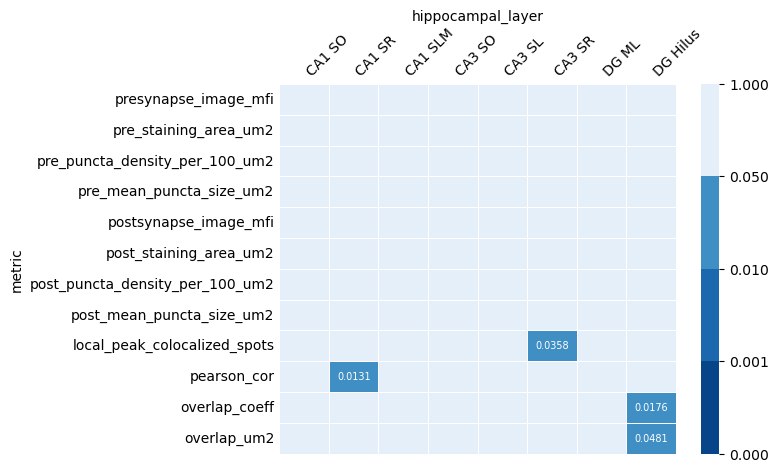

In [109]:
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 1], cmap.N)

mask = df_vgat_2 < 0.1
annotations = df_vgat_2.applymap(lambda x: f'{x:.4f}' if x < 0.05 else '')


ax = sns.heatmap(data=df_vgat_2, annot=annotations, fmt = "", annot_kws={"fontsize": 7}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.show()

/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/1496055320.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_2 = df_vglut1_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/1496055320.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/1496055320.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_4 = df_vgat_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')


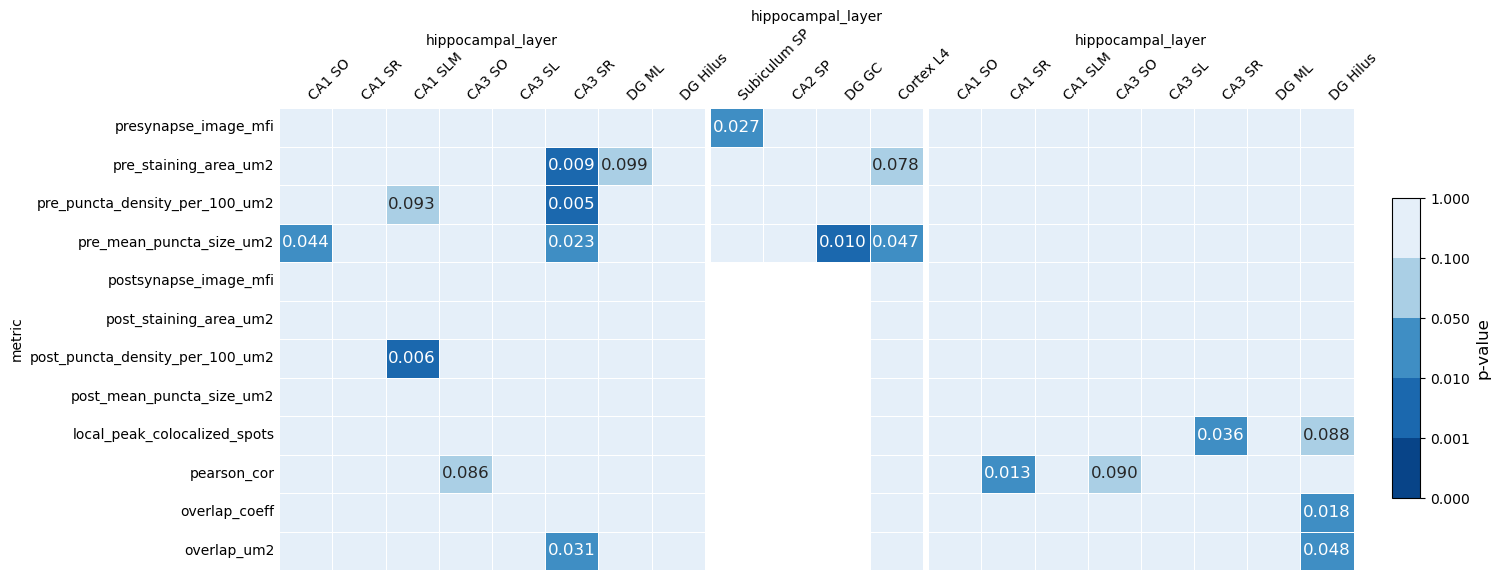

In [110]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns

# Define a discrete colormap
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

# Format annotations with 3 decimal places
annotations_2 = df_vglut1_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
annotations_4 = df_vgat_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')

# Set up the figure and gridspec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 4, width_ratios=[len(df_vglut1_2.columns), len(df_vglut2_2.columns), len(df_vgat_2.columns), 0.1], wspace=0.02)

# Create the first heatmap
ax0 = plt.subplot(gs[0])
sns.heatmap(df_vglut1_2, annot=annotations_2, fmt='', annot_kws={"fontsize": 12}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax0, cbar=False)
ax0.xaxis.set_label_position('top')
ax0.xaxis.tick_top()
ax0.tick_params(axis='x', length=0)
ax0.tick_params(axis='y', length=0)
plt.sca(ax0)
plt.xticks(rotation=45, ha='left')

# Create the second heatmap
ax1 = plt.subplot(gs[1])
heatmap = sns.heatmap(df_vglut2_2, annot=annotations_3, fmt='', annot_kws={"fontsize": 12}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax1, cbar=False, yticklabels=False)
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.tick_params(axis='x', length=0)
ax1.tick_params(axis='y', length=0)
ax1.set_ylabel('')  # Remove the y-axis label
plt.sca(ax1)
plt.xticks(rotation=45, ha='left')

# Create the third heatmap
ax2 = plt.subplot(gs[2])
heatmap_2 = sns.heatmap(df_vgat_2, annot=annotations_4, fmt='', annot_kws={"fontsize": 12}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax2, cbar=False, yticklabels=False)
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()
ax2.tick_params(axis='x', length=0)
ax2.tick_params(axis='y', length=0)
ax2.set_ylabel('')  # Remove the y-axis label
plt.sca(ax2)
plt.xticks(rotation=45, ha='left')

# Create a separate axes for the legend
cax = fig.add_axes([0.92, 0.23, 0.02, 0.5])  # [left, bottom, width, height]
fig.colorbar(heatmap.collections[0], cax=cax, orientation='vertical')
cax.set_ylabel('p-value', fontsize=12)
cax.tick_params(labelsize=10)  # Smaller colorbar ticks

plt.show()


/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/4250385726.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_2 = df_vglut1_2.applymap(lambda x: f'{x:.3f}' if x < 0.5 else '')
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/4250385726.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.5 else '')
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_95425/4250385726.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_4 = df_vgat_2.applymap(lambda x: f'{x:.3f}' if x < 0.5 else '')


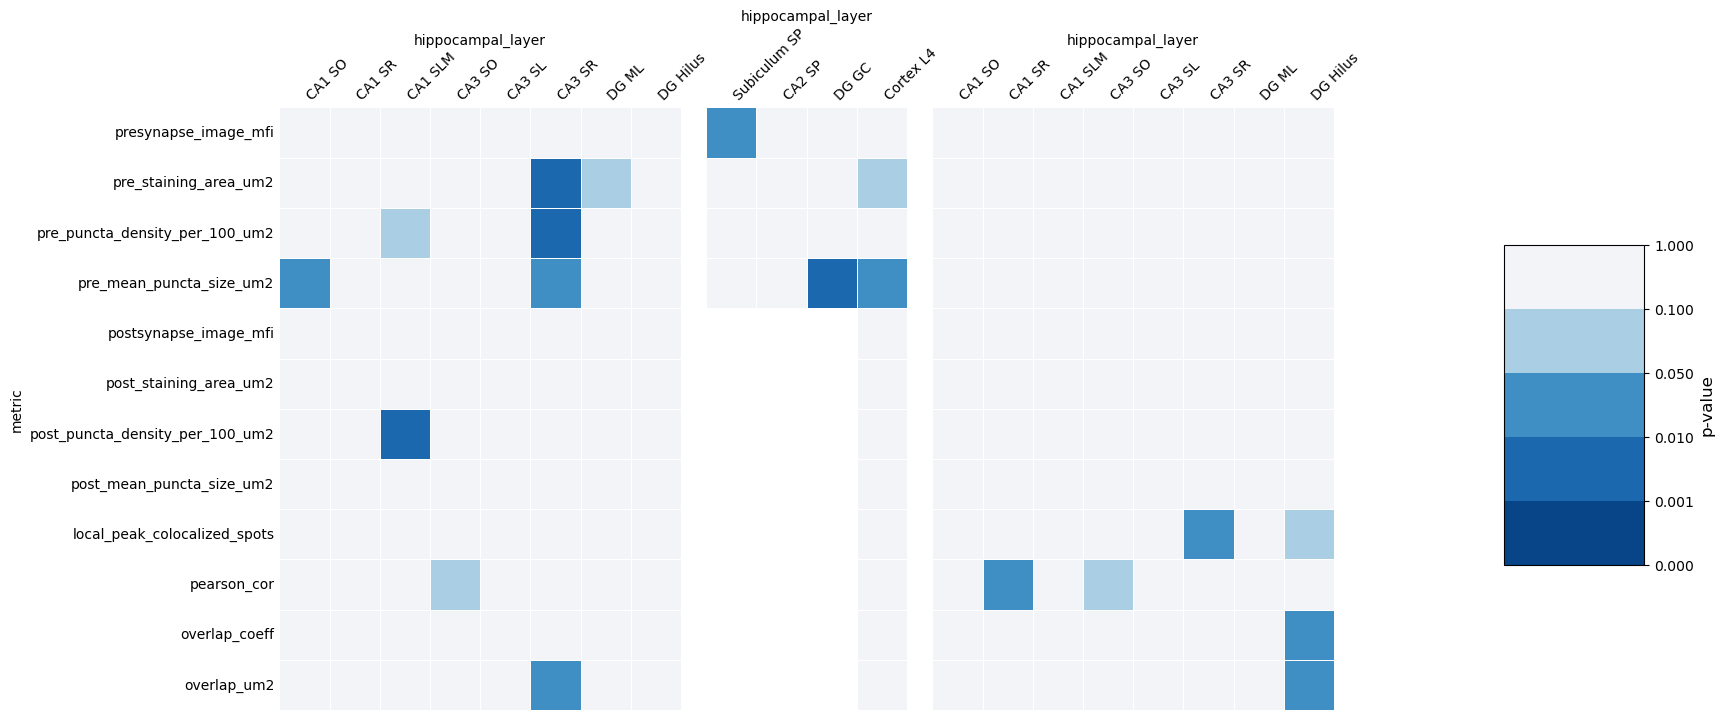

In [111]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns

# Define a discrete colormap
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4','#aacfe5', '#f2f4f7'])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

# Format annotations with 3 decimal places
annotations_2 = df_vglut1_2.applymap(lambda x: f'{x:.3f}' if x < 0.5 else '')
annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.5 else '')
annotations_4 = df_vgat_2.applymap(lambda x: f'{x:.3f}' if x < 0.5 else '')

# Set up the figure and gridspec
fig = plt.figure(figsize=(14, 8))  # Adjust the figure size if needed
gs = gridspec.GridSpec(1, 4, width_ratios=[len(df_vglut1_2.columns), len(df_vglut2_2.columns), len(df_vgat_2.columns), 0.1], wspace=0.1)  # Reduced the space between plots

# Create the first (vglut1) heatmap
ax0 = plt.subplot(gs[0], aspect='equal')
sns.heatmap(df_vglut1_2, annot=False, fmt='', annot_kws={"fontsize": 6}, linewidth=0.5, linecolor='white', vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax0, cbar=False)
ax0.xaxis.set_label_position('top')
ax0.xaxis.tick_top()
ax0.tick_params(axis='x', length=0)
ax0.tick_params(axis='y', length=0)
plt.sca(ax0)
plt.xticks(rotation=45, ha='left')
ax0.hlines(df_vglut1_2.shape[0], *ax0.get_xlim(), color='grey', linewidth=0.5)  # Add line at the bottom
ax0.vlines(df_vglut1_2.shape[1], *ax0.get_ylim(), color='grey', linewidth=0.5)  # Add line at the right

# Create the second (vglut2) heatmap
ax1 = plt.subplot(gs[1], aspect='equal')
heatmap = sns.heatmap(df_vglut2_2, annot=False, fmt='', annot_kws={"fontsize": 6}, linewidth=0.5, linecolor='white', vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax1, cbar=False, yticklabels=False)
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.tick_params(axis='x', length=0)
ax1.tick_params(axis='y', length=0)
ax1.set_ylabel('')  # Remove the y-axis label
plt.sca(ax1)
plt.xticks(rotation=45, ha='left')
ax1.hlines(df_vglut2_2.shape[0], *ax1.get_xlim(), color='grey', linewidth=0.5)  # Add line at the bottom
ax1.vlines(df_vglut2_2.shape[1], *ax1.get_ylim(), color='grey', linewidth=0.5)  # Add line at the right

# Create the third (vgat) heatmap
ax2 = plt.subplot(gs[2], aspect='equal')
heatmap_2 = sns.heatmap(df_vgat_2, annot=False, fmt='', annot_kws={"fontsize": 6}, linewidth=0.5, linecolor='white', vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax2, cbar=False, yticklabels=False)
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()
ax2.tick_params(axis='x', length=0)
ax2.tick_params(axis='y', length=0)
ax2.set_ylabel('')  # Remove the y-axis label
plt.sca(ax2)
plt.xticks(rotation=45, ha='left')
ax2.hlines(df_vgat_2.shape[0], *ax2.get_xlim(), color='grey', linewidth=0.5)  # Add line at the bottom
ax2.vlines(df_vgat_2.shape[1], *ax2.get_ylim(), color='grey', linewidth=0.5)  # Add line at the right

# Create a separate axes for the legend
cax = fig.add_axes([1, 0.3, 0.1, 0.4])  # Adjusted the height to be more centered
fig.colorbar(heatmap.collections[0], cax=cax, orientation='vertical')
cax.set_ylabel('p-value', fontsize=12)
cax.tick_params(labelsize=10)  # Smaller colorbar ticks

plt.show()

In [604]:
### DOTPLOT ####

In [2]:
from synapse_counting import results_plotting

In [70]:
# Candidate to make the heatmap of
protein = "VCAM1"

In [71]:
def cohen_d_paired(df, column_1, column_2):

    sample1 = df[column_1].values
    sample2 = df[column_2].values
    
    # Calculate the differences
    differences = sample1 - sample2
    
    # Calculate the mean and standard deviation of the differences
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)  # Sample standard deviation
    
    # Avoid division by zero
    if std_diff == 0:
        return np.nan  # Return NaN if the standard deviation is zero to avoid division by zero
    
    # Calculate Cohen's d
    cohen_d = mean_diff / std_diff
    
    return -cohen_d

In [72]:
# order to show the metrics and hippocampal layers

metric_order = [
    "presynapse_image_mfi", 
    "pre_staining_area_um2",
    "pre_puncta_density_per_100_um2",
    "pre_mean_puncta_size_um2",
    "postsynapse_image_mfi",
    "post_staining_area_um2",
    "post_puncta_density_per_100_um2",
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ]

vglut1_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

vglut2_hippocampal_layer_order = [
    "Subiculum SP",
    "CA2 SP",
    "DG GC",
    "Cortex L4"
    ]

vgat_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

In [73]:
# reading in the VGLUT1-PSD95 dataset
vglut1_psd95_results_file = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGLUT1-PSD95_output_data/metric_results.csv"
vglut1_psd95_results = pd.read_csv(vglut1_psd95_results_file)
vglut1_psd95_results.shape

(176, 23)

In [74]:
# getting the statistics and cohen's D
vglut1_statistcs_instance = results_plotting.PlotResults(df = vglut1_psd95_results, candidate_gRNA = f"{protein}" + "-gRNA", name_of_plot = "doesnt_matter")
vglut1_p_value_results = []
vglut1_cohen_d_results =[]

for hippocampal_layer in vglut1_hippocampal_layer_order:
    for metric in metric_order:
        _ , _, replicates_df , _ , p_value = vglut1_statistcs_instance.check_statistics(hippocampal_layer = hippocampal_layer, metric = metric)
        vglut1_p_value_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "p_value": p_value})
        cohen_d = cohen_d_paired(df=replicates_df, column_1= "LacZ-gRNA", column_2=f"{protein}-gRNA")
        vglut1_cohen_d_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "cohen_d": cohen_d})

In [75]:
df_vglut1_p_value_results = pd.DataFrame(vglut1_p_value_results) 
df_vglut1_p_value_results.head(2)

,hippocampal_layer,metric,p_value
0,CA1 SO,presynapse_image_mfi,0.036487
1,CA1 SO,pre_staining_area_um2,0.466850


In [76]:
df_wide_vglut1_p_value = df_vglut1_p_value_results.pivot(index="metric", columns="hippocampal_layer", values="p_value").reindex(metric_order)
df_wide_vglut1_p_value_2 = df_wide_vglut1_p_value[vglut1_hippocampal_layer_order]
df_wide_vglut1_p_value_2.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
metric,,,,,,,,
presynapse_image_mfi,0.036487,0.277754,0.962370,0.022510,0.011441,0.000840,0.088051,0.058350
pre_staining_area_um2,0.466850,0.298144,0.249161,0.618954,0.837219,0.210997,0.801128,0.393717
pre_puncta_density_per_100_um2,0.572791,0.454282,0.436702,0.357121,0.414848,0.091976,0.280806,0.687277
pre_mean_puncta_size_um2,0.923379,0.125394,0.238073,0.960669,0.406455,0.323942,0.572599,0.888058
postsynapse_image_mfi,0.855759,0.118303,0.897151,0.023217,0.169400,0.840753,0.208252,0.446388
post_staining_area_um2,0.755015,0.308545,0.782553,0.642750,0.954016,0.522367,0.525695,0.998795
post_puncta_density_per_100_um2,0.816116,0.216605,0.723442,0.518395,0.738104,0.651935,0.984687,0.498757
post_mean_puncta_size_um2,0.416695,0.636948,0.789960,0.152173,0.338470,0.655923,0.442502,0.276608
local_peak_colocalized_spots,0.188478,0.289729,0.813102,0.054809,0.065552,0.055427,0.263135,0.045393


In [77]:
df_vglut1_cohen_d_results = pd.DataFrame(vglut1_cohen_d_results) 
df_vglut1_cohen_d_results.head(2)

,hippocampal_layer,metric,cohen_d
0,CA1 SO,presynapse_image_mfi,-1.805317
1,CA1 SO,pre_staining_area_um2,0.415582


In [78]:
df_wide_vglut1_cohen_d = df_vglut1_cohen_d_results.pivot(index="metric", columns="hippocampal_layer", values="cohen_d").reindex(metric_order)
df_wide_vglut1_cohen_d_2 = df_wide_vglut1_cohen_d[vglut1_hippocampal_layer_order]
df_wide_vglut1_cohen_d_2.head(2)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
metric,,,,,,,,
presynapse_image_mfi,-1.805317,-0.661301,0.025610,-2.172401,-2.783199,-6.853360,-1.247780,-1.492646
pre_staining_area_um2,0.415582,0.627817,0.712916,-0.276374,0.111948,0.792834,-0.137529,-0.496728


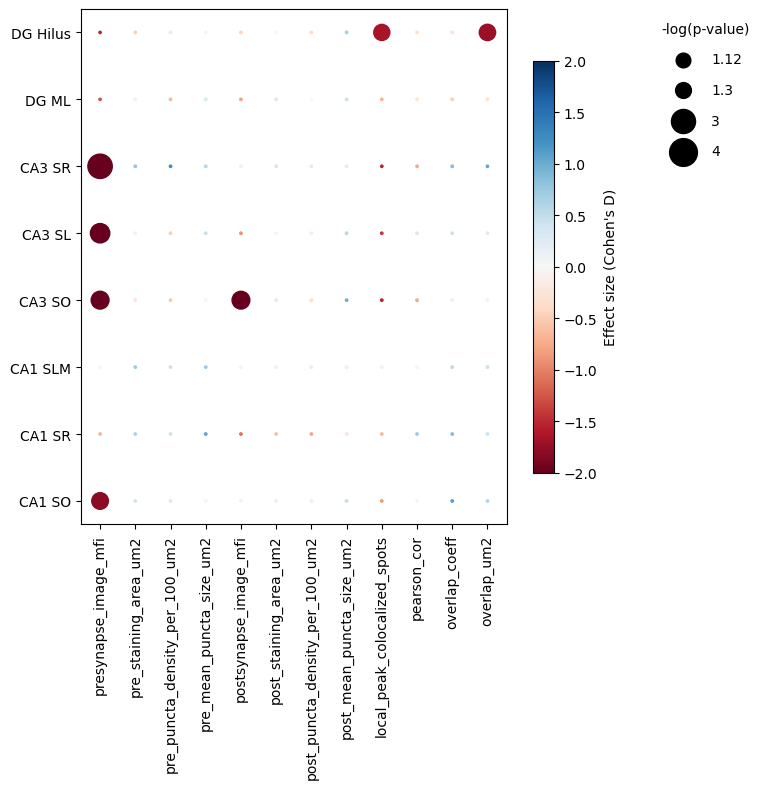

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize

# Now plot the dot plot
plt.figure(figsize=(8, 8))

# Flatten the data to plot in one go
x_vals = np.repeat(range(len(metric_order)), len(vglut1_hippocampal_layer_order))
y_vals = np.tile(range(len(vglut1_hippocampal_layer_order)), len(metric_order))
sizes = df_wide_vglut1_p_value_2.values.flatten() 
sizes_log = -np.log10(sizes)*100 # size represents % expressing
colors = df_wide_vglut1_cohen_d_2.values.flatten()      # color represents log2 expression

# Apply the cutoff of -log10(p-value) >= 1.3
cutoff = 1.3
sizes_log[sizes_log < (cutoff * 100)] = 3  # Set dot size to 0 for values below cutoff

# Create scatter plot and get mappable for colorbar
norm = Normalize(vmin=-2, vmax=2)
scatter = plt.scatter(x_vals, y_vals, s=sizes_log, c=colors, cmap='RdBu', norm=norm)

# Set x and y ticks
plt.xticks(range(len(metric_order)), metric_order, rotation=90)
plt.yticks(range(len(vglut1_hippocampal_layer_order)), vglut1_hippocampal_layer_order)

# Create a smaller colorbar and position it below the dot size legend
cbar = plt.colorbar(scatter, shrink=0.8)  # Shrink the colorbar
cbar.set_label("Effect size (Cohen's D)")

# Create a legend for the dot sizes (representing % expressing)
size_legend_labels = [1.12, 1.3, 3, 4]  # Customize these values as necessary
size_legend = [plt.scatter([], [], s=size*100, edgecolor='black', facecolor='black') for size in size_legend_labels]

# Add the custom legend with improved spacing
plt.legend(size_legend, [f'{label}' for label in size_legend_labels], 
           title='-log(p-value)', loc='upper right', bbox_to_anchor=(1.6, 1),
           handletextpad=1, labelspacing=1.2, frameon=False)

# Reposition the colorbar below the size legend
cbar.ax.set_position([0.5, 0.3, 0.2, 0.3])  # [left, bottom, width, height] positioning

plt.tight_layout()
plt.show()

In [80]:
# reading in the VGLUT2-PSD95 dataset
vglut2_psd95_results_file = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGLUT2-PSD95_output_data/metric_results.csv"
vglut2_psd95_results = pd.read_csv(vglut2_psd95_results_file)
vglut2_psd95_results.shape

(88, 23)

In [81]:
rows_to_set_na = [
    "postsynapse_image_mfi", 
    "post_staining_area_um2", 
    "post_puncta_density_per_100_um2", 
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ] 

column_to_exclude = "Cortex L4"  # Column to exclude from NA

In [82]:
# getting the statistics and cohen's D
vglut2_statistcs_instance = results_plotting.PlotResults(df = vglut2_psd95_results, candidate_gRNA = f"{protein}" + "-gRNA", name_of_plot = "doesnt_matter")
vglut2_p_value_results = []
vglut2_cohen_d_results =[]

for hippocampal_layer in vglut2_hippocampal_layer_order:
    for metric in metric_order:
        _ , _, replicates_df , _ , p_value = vglut2_statistcs_instance.check_statistics(hippocampal_layer = hippocampal_layer, metric = metric)
        vglut2_p_value_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "p_value": p_value})
        cohen_d = cohen_d_paired(df=replicates_df, column_1= "LacZ-gRNA", column_2=f"{protein}-gRNA")
        vglut2_cohen_d_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "cohen_d": cohen_d})

In [83]:
df_vglut2_p_value_results = pd.DataFrame(vglut2_p_value_results) 

df_wide_vglut2_p_value = df_vglut2_p_value_results.pivot(index="metric", columns="hippocampal_layer", values="p_value").reindex(metric_order)
df_wide_vglut2_p_value_2 = df_wide_vglut2_p_value[vglut2_hippocampal_layer_order]

df_wide_vglut2_p_value_2.loc[rows_to_set_na, df_wide_vglut2_p_value_2.columns != column_to_exclude] = np.nan
df_wide_vglut2_p_value_2.head(10)

hippocampal_layer,Subiculum SP,CA2 SP,DG GC,Cortex L4
metric,,,,
presynapse_image_mfi,0.876430,0.134020,0.493108,0.567251
pre_staining_area_um2,0.387017,0.790702,0.372079,0.989965
pre_puncta_density_per_100_um2,0.395320,0.959233,0.459859,0.106828
pre_mean_puncta_size_um2,0.882214,0.655283,0.807843,0.147142
postsynapse_image_mfi,NaN,NaN,NaN,0.524910
post_staining_area_um2,NaN,NaN,NaN,0.741595
post_puncta_density_per_100_um2,NaN,NaN,NaN,0.914616
post_mean_puncta_size_um2,NaN,NaN,NaN,0.086714
local_peak_colocalized_spots,NaN,NaN,NaN,0.363349


In [84]:
df_vglut2_cohen_d_results = pd.DataFrame(vglut2_cohen_d_results) 
df_wide_vglut2_cohen_d = df_vglut2_cohen_d_results.pivot(index="metric", columns="hippocampal_layer", values="cohen_d").reindex(metric_order)
df_wide_vglut2_cohen_d_2 = df_wide_vglut2_cohen_d[vglut2_hippocampal_layer_order]
df_wide_vglut2_cohen_d_2.loc[rows_to_set_na, df_wide_vglut2_cohen_d_2.columns != column_to_exclude] = np.nan
df_wide_vglut2_cohen_d_2.head(10)

hippocampal_layer,Subiculum SP,CA2 SP,DG GC,Cortex L4
metric,,,,
presynapse_image_mfi,0.084582,-1.020105,0.389179,0.320393
pre_staining_area_um2,-0.504842,0.145003,0.523426,-0.006826
pre_puncta_density_per_100_um2,-0.494806,-0.027748,0.422827,1.140547
pre_mean_puncta_size_um2,-0.080576,0.246944,0.132736,-0.971974
postsynapse_image_mfi,NaN,NaN,NaN,0.358730
post_staining_area_um2,NaN,NaN,NaN,-0.180818
post_puncta_density_per_100_um2,NaN,NaN,NaN,-0.058251
post_mean_puncta_size_um2,NaN,NaN,NaN,-1.256463
local_peak_colocalized_spots,NaN,NaN,NaN,0.534622


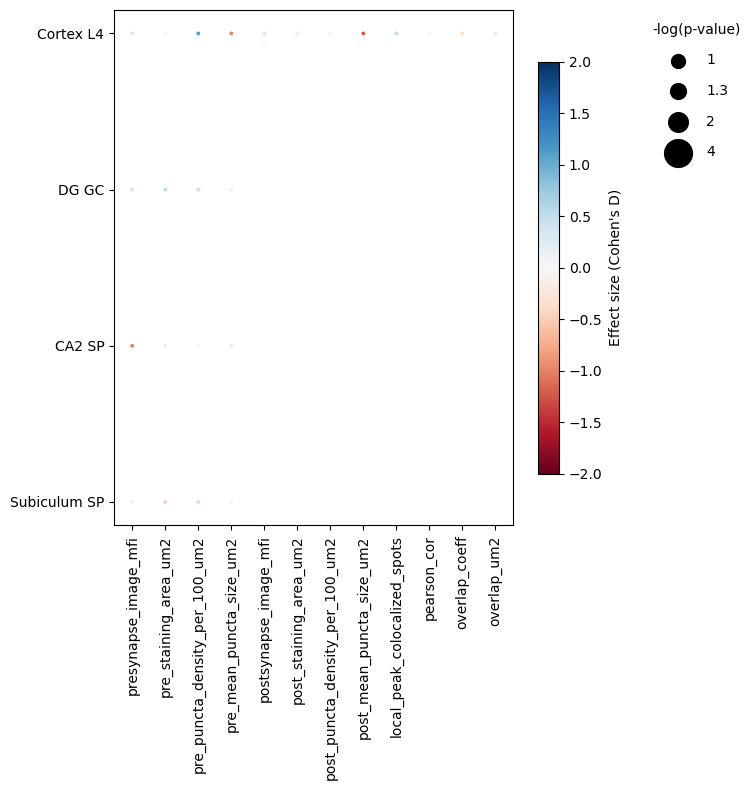

In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize

# Now plot the dot plot
plt.figure(figsize=(8, 8))

# Flatten the data to plot in one go
x_vals = np.repeat(range(len(metric_order)), len(vglut2_hippocampal_layer_order))
y_vals = np.tile(range(len(vglut2_hippocampal_layer_order)), len(metric_order))
sizes = df_wide_vglut2_p_value_2.values.flatten() 
sizes_log = -np.log10(sizes)*100 # size represents % expressing
colors = df_wide_vglut2_cohen_d_2.values.flatten()      # color represents log2 expression

# Apply the cutoff of -log10(p-value) >= 1.3
cutoff = 1.3
sizes_log[sizes_log < (cutoff * 100)] = 3  # Set dot size to 0 for values below cutoff

# Create scatter plot and get mappable for colorbar
norm = Normalize(vmin=-2, vmax=2)
scatter = plt.scatter(x_vals, y_vals, s=sizes_log, c=colors, cmap='RdBu', norm=norm)

# Set x and y ticks
plt.xticks(range(len(metric_order)), metric_order, rotation=90)
plt.yticks(range(len(vglut2_hippocampal_layer_order)), vglut2_hippocampal_layer_order)

# Create a smaller colorbar and position it below the dot size legend
cbar = plt.colorbar(scatter, shrink=0.8)  # Shrink the colorbar
cbar.set_label("Effect size (Cohen's D)")

# Create a legend for the dot sizes (representing % expressing)
size_legend_labels = [1, 1.3, 2, 4]  # Customize these values as necessary
size_legend = [plt.scatter([], [], s=size*100, edgecolor='black', facecolor='black') for size in size_legend_labels]

# Add the custom legend with improved spacing
plt.legend(size_legend, [f'{label}' for label in size_legend_labels], 
           title='-log(p-value)', loc='upper right', bbox_to_anchor=(1.6, 1),
           handletextpad=1, labelspacing=1.2, frameon=False)

# Reposition the colorbar below the size legend
cbar.ax.set_position([0.5, 0.3, 0.2, 0.3])  # [left, bottom, width, height] positioning

plt.tight_layout()
plt.show()

In [86]:
# reading in the VGAT-GEPH dataset
vgat_geph_results_file = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGAT-GEPH_output_data/metric_results.csv"
vgat_geph_results = pd.read_csv(vgat_geph_results_file)
vgat_geph_results.shape

(176, 23)

In [87]:
# getting the statistics and cohen's D
vgat_statistcs_instance = results_plotting.PlotResults(df = vgat_geph_results, candidate_gRNA = f"{protein}" + "-gRNA", name_of_plot = "doesnt_matter")
vgat_p_value_results = []
vgat_cohen_d_results =[]

for hippocampal_layer in vgat_hippocampal_layer_order:
    for metric in metric_order:
        _ , _, replicates_df , _ , p_value = vgat_statistcs_instance.check_statistics(hippocampal_layer = hippocampal_layer, metric = metric)
        vgat_p_value_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "p_value": p_value})
        cohen_d = cohen_d_paired(df=replicates_df, column_1= "LacZ-gRNA", column_2=f"{protein}-gRNA")
        vgat_cohen_d_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "cohen_d": cohen_d})

In [88]:
df_vgat_p_value_results = pd.DataFrame(vgat_p_value_results) 
df_wide_vgat_p_value = df_vgat_p_value_results.pivot(index="metric", columns="hippocampal_layer", values="p_value").reindex(metric_order)
df_wide_vgat_p_value_2 = df_wide_vgat_p_value[vgat_hippocampal_layer_order]
df_wide_vgat_p_value_2.head(2)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
metric,,,,,,,,
presynapse_image_mfi,0.809081,0.084775,0.644048,0.094863,0.26716,0.020485,0.120562,0.340677
pre_staining_area_um2,0.323242,0.519829,0.358981,0.090698,0.09643,0.758617,0.369361,0.585257


In [89]:
df_vgat_cohen_d_results = pd.DataFrame(vgat_cohen_d_results) 
df_wide_vgat_cohen_d = df_vgat_cohen_d_results.pivot(index="metric", columns="hippocampal_layer", values="cohen_d").reindex(metric_order)
df_wide_vgat_cohen_d_2 = df_wide_vgat_cohen_d[vgat_hippocampal_layer_order]
df_wide_vgat_cohen_d_2.head(2)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
metric,,,,,,,,
presynapse_image_mfi,-0.131854,-1.269353,-0.255929,-1.205901,-0.679734,-2.250224,-1.075640,-0.564976
pre_staining_area_um2,0.589716,-0.363492,-0.540323,-1.231050,1.196789,-0.168279,-0.526884,0.304747


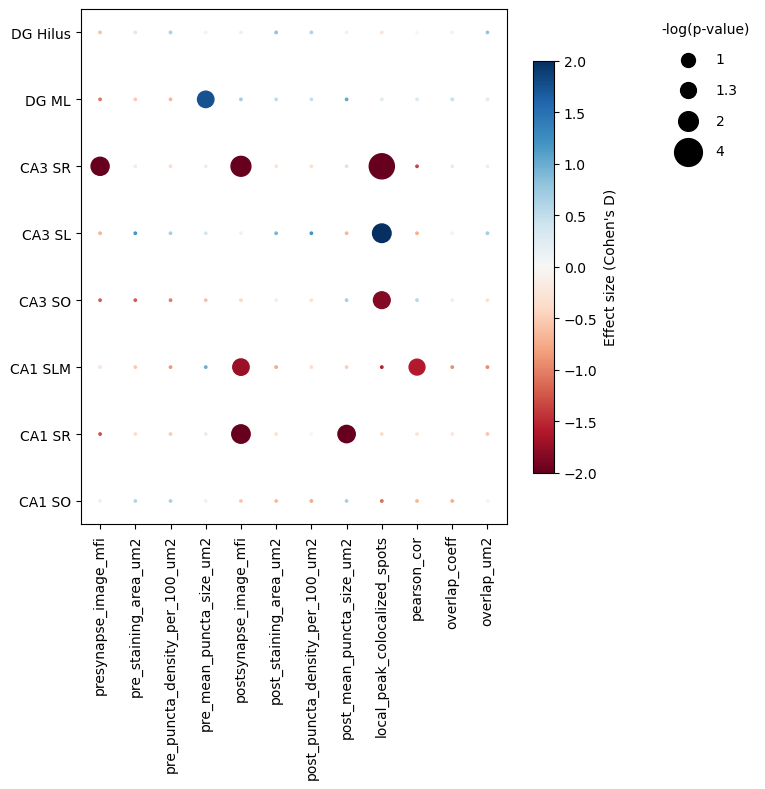

In [90]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize

# Now plot the dot plot
plt.figure(figsize=(8, 8))

# Flatten the data to plot in one go
x_vals = np.repeat(range(len(metric_order)), len(vgat_hippocampal_layer_order))
y_vals = np.tile(range(len(vgat_hippocampal_layer_order)), len(metric_order))
sizes = df_wide_vgat_p_value_2.values.flatten() 
sizes_log = -np.log10(sizes)*100 # size represents % expressing
colors = df_wide_vgat_cohen_d_2.values.flatten()      # color represents log2 expression

# Apply the cutoff of -log10(p-value) >= 1.3
cutoff = 1.3
sizes_log[sizes_log < (cutoff * 100)] = 3  # Set dot size to 0 for values below cutoff

# Create scatter plot and get mappable for colorbar
norm = Normalize(vmin=-2, vmax=2)
scatter = plt.scatter(x_vals, y_vals, s=sizes_log, c=colors, cmap='RdBu', norm=norm)

# Set x and y ticks
plt.xticks(range(len(metric_order)), metric_order, rotation=90)
plt.yticks(range(len(vgat_hippocampal_layer_order)), vgat_hippocampal_layer_order)

# Create a smaller colorbar and position it below the dot size legend
cbar = plt.colorbar(scatter, shrink=0.8)  # Shrink the colorbar
cbar.set_label("Effect size (Cohen's D)")

# Create a legend for the dot sizes (representing % expressing)
size_legend_labels = [1, 1.3, 2, 4]  # Customize these values as necessary
size_legend = [plt.scatter([], [], s=size*100, edgecolor='black', facecolor='black') for size in size_legend_labels]

# Add the custom legend with improved spacing
plt.legend(size_legend, [f'{label}' for label in size_legend_labels], 
           title='-log(p-value)', loc='upper right', bbox_to_anchor=(1.6, 1),
           handletextpad=1, labelspacing=1.2, frameon=False)

# Reposition the colorbar below the size legend
cbar.ax.set_position([0.5, 0.3, 0.2, 0.3])  # [left, bottom, width, height] positioning

plt.tight_layout()
plt.show()

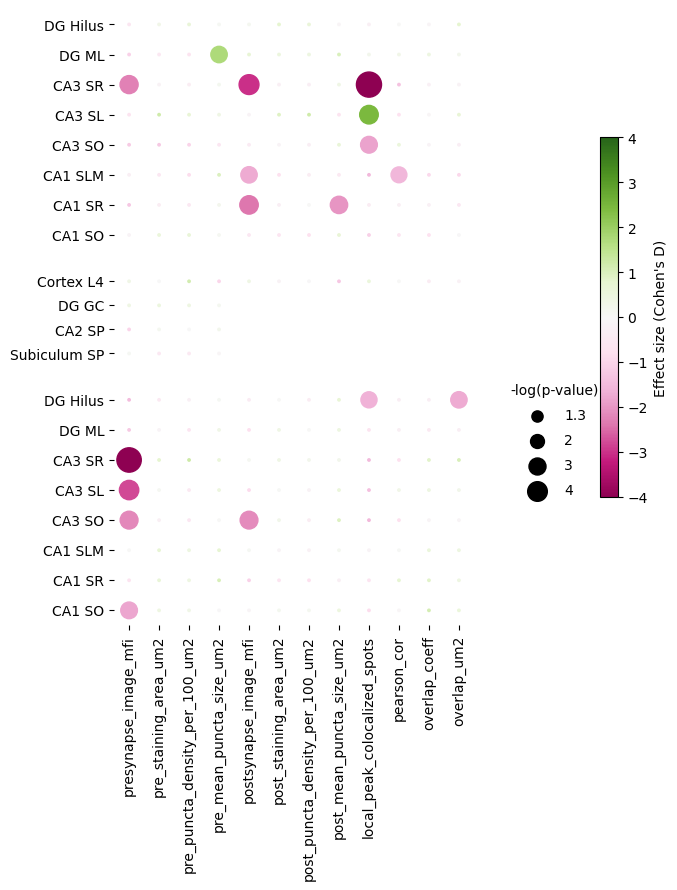

In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize

# Set up the figure
fig = plt.figure(figsize=(6.5, 8))

# Create a grid for the main plots and the legend
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1], height_ratios=[1, 0.4, 1], hspace=0.1, wspace=0.1)

# Data and parameters for each plot
data_sets = [
    (df_wide_vgat_p_value_2, df_wide_vgat_cohen_d_2, vgat_hippocampal_layer_order),
    (df_wide_vglut2_p_value_2, df_wide_vglut2_cohen_d_2, vglut2_hippocampal_layer_order),
    (df_wide_vglut1_p_value_2, df_wide_vglut1_cohen_d_2, vglut1_hippocampal_layer_order)
]
titles = ['VGAT', 'VGLUT2', 'VGLUT1']

# Create subplots for the main plots
axes = [fig.add_subplot(gs[i, 0]) for i in range(3)]

for i, (ax, (df_p_value, df_cohen_d, hippocampal_layer_order)) in enumerate(zip(axes, data_sets)):
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Flatten the data
    x_vals = np.repeat(range(len(metric_order)), len(hippocampal_layer_order))
    y_vals = np.tile(range(len(hippocampal_layer_order)), len(metric_order))
    sizes = df_p_value.values.flatten()
    sizes_log = -np.log10(sizes) * 100
    colors = df_cohen_d.values.flatten()

    # Apply cutoff
    cutoff = 1.3
    sizes_log[sizes_log < (cutoff * 100)] = 3

    # Create scatter plot
    norm = Normalize(vmin=-4, vmax=4)
    scatter = ax.scatter(x_vals, y_vals, s=sizes_log, c=colors, cmap='PiYG', norm=norm)
    
    # Adjust x and y limits to avoid cutting off points
    ax.set_xlim(-0.5, len(metric_order) - 0.5)
    ax.set_ylim(-0.5, len(hippocampal_layer_order) - 0.5)
    
    # Set y ticks for each plot
    ax.set_yticks(range(len(hippocampal_layer_order)))
    ax.set_yticklabels(hippocampal_layer_order)

    # Only set x ticks for the bottom plot
    if i == 2:  # Bottom plot
        ax.set_xticks(range(len(metric_order)))
        ax.set_xticklabels(metric_order, rotation=90)
    else:
        ax.set_xticks([])

    # Set title for each subplot
    #ax.set_title(titles[i], y=1.0, pad=-14)

# Create a subplot for the legends
legend_ax = fig.add_subplot(gs[:, 1])
legend_ax.axis('off')

# Add a colorbar
cbar = fig.colorbar(scatter, ax=legend_ax, shrink=0.8, aspect=20, pad=0.05)
cbar.set_label("Effect size (Cohen's D)")

# Create a legend for dot sizes
size_legend_labels = [1.3, 2, 3, 4]
size_legend = [plt.scatter([], [], s=size*50, edgecolor='black', facecolor='black') for size in size_legend_labels]
legend_ax.legend(size_legend, [f'{label}' for label in size_legend_labels],
                 title='-log(p-value)', loc='center left', bbox_to_anchor=(0, 0.3),
                 handletextpad=1, labelspacing=0.8, frameon=False)

plt.savefig(f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}_dotplot", dpi=600)
#plt.tight_layout()
plt.show()